In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

# Affichage plus agréable
pd.set_option("display.max_columns", None)

# Style des graphiques
sns.set_theme(style="whitegrid")

In [9]:
df = pd.read_csv("../datasets/Titanic-Dataset.csv")

In [10]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
df.shape

(891, 12)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [13]:
df.describe(include="all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [14]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [15]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [16]:
(
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

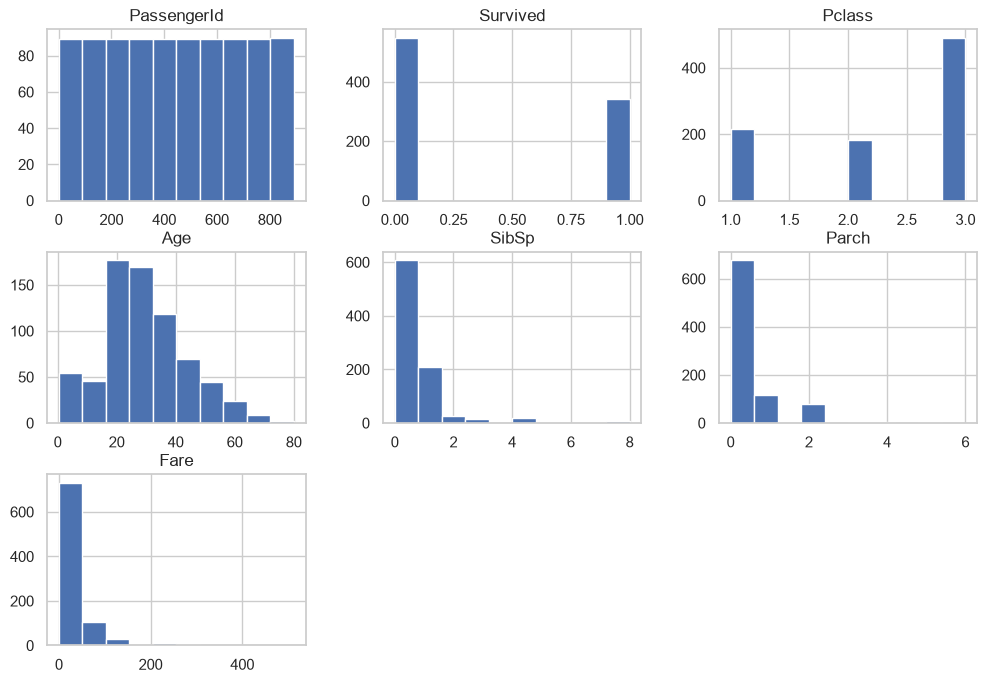

In [17]:
df.hist(figsize=(12,8))
plt.show()

In [18]:
for col in df.select_dtypes(include="object"):
    print("="*30)
    print(col)
    print(df[col].value_counts())

Name
Name
Braund, Mr. Owen Harris                                1
Cumings, Mrs. John Bradley (Florence Briggs Thayer)    1
Heikkinen, Miss. Laina                                 1
Futrelle, Mrs. Jacques Heath (Lily May Peel)           1
Allen, Mr. William Henry                               1
                                                      ..
Montvila, Rev. Juozas                                  1
Graham, Miss. Margaret Edith                           1
Johnston, Miss. Catherine Helen "Carrie"               1
Behr, Mr. Karl Howell                                  1
Dooley, Mr. Patrick                                    1
Name: count, Length: 891, dtype: int64
Sex
Sex
male      577
female    314
Name: count, dtype: int64
Ticket
Ticket
347082             7
1601               7
CA. 2343           7
3101295            6
CA 2144            6
                  ..
SOTON/OQ 392076    1
211536             1
112053             1
111369             1
370376             1
Name: count, Leng

C:\Users\HP\AppData\Local\Temp\ipykernel_10424\4101703110.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object"):


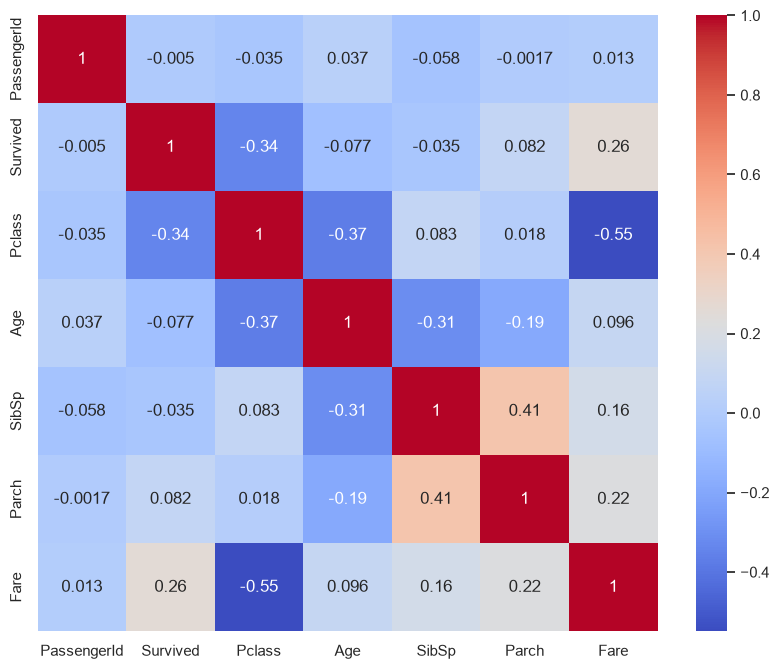

In [19]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [20]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Name            0.000000
Pclass          0.000000
Survived        0.000000
Sex             0.000000
Parch           0.000000
SibSp           0.000000
Fare            0.000000
Ticket          0.000000
dtype: float64

In [21]:
df = df.drop(columns=["Cabin"])
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='str')

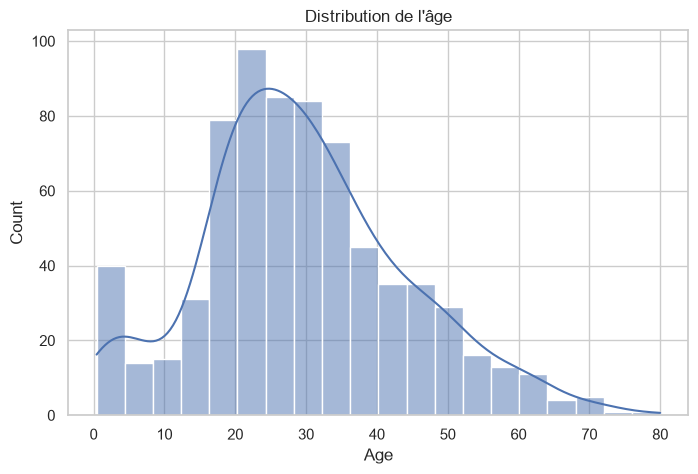

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], kde=True)
plt.title("Distribution de l'âge")
plt.show()

In [23]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [24]:
df["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [25]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [26]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

structure, data types, and identify missing values.
* Dropped the **`Cabin`** column because it contained **687 missing values out of 891 observations (approximately 77%)**. Such a high proportion of missing data would make imputation unreliable and could introduce significant bias.
* Filled the **177 missing values** in the **`Age`** column using the **median**. The age distribution is slightly **right-skewed**, meaning the mean could be influenced by older passengers (outliers). The median is more robust to extreme values and better represents the central tendency of the data.
* Filled the **2 ## Data Cleaning Summary

* Performed an initial inspection of the dataset using `shape`, `info()`, and `describe()` to understand its missing values** in the **`Embarked`** column using the **mode**, as it is the most appropriate measure for categorical variables.
* Verified that the dataset contains **no remaining missing values**, making it ready for further analysis.

## Initial Interpretation

The age distribution shows that most passengers were **young adults between 20 and 30 years old**, with fewer older passengers, resulting in a slightly right-skewed distribution. This observation supports the choice of using the **median** instead of the **mean** for imputing missing ages. At this stage, the dataset is clean and suitable for exploratory data analysis (EDA) and machine learning tasks.

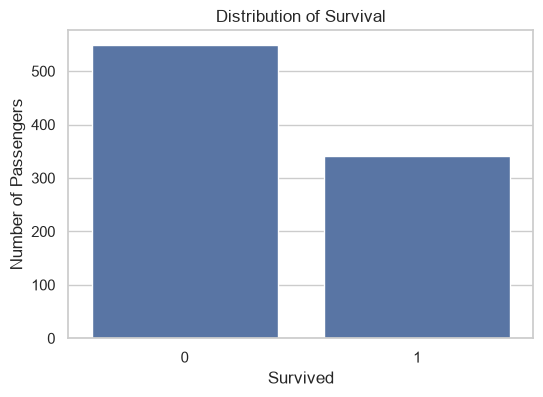

In [27]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Survived")

plt.title("Distribution of Survival")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")

plt.show()

Text(0, 0.5, 'Sex Count')

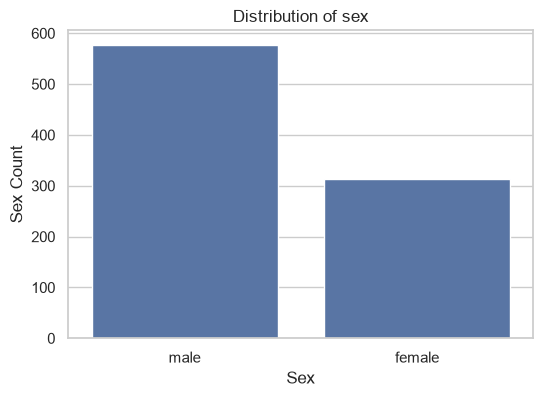

In [28]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Sex")

plt.title("Distribution of sex")
plt.xlabel("Sex")
plt.ylabel("Sex Count")

Text(0, 0.5, 'Survived Count')

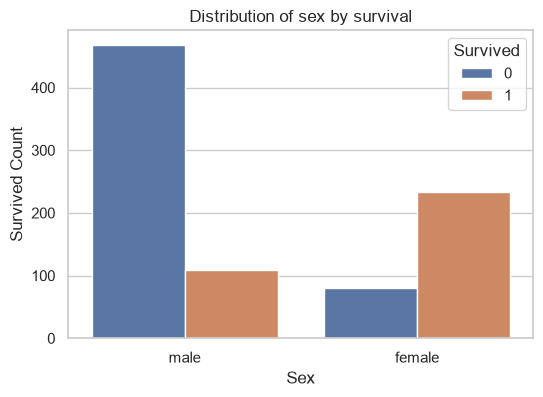

In [29]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Sex", hue="Survived")

plt.title("Distribution of sex by survival")
plt.xlabel("Sex")
plt.ylabel("Survived Count")

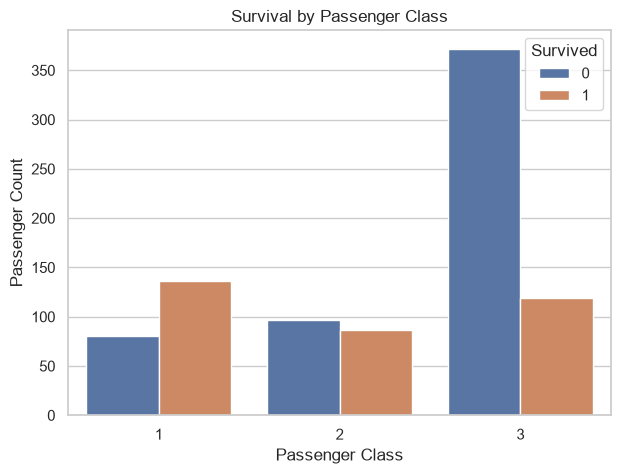

In [30]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Pclass",
    hue="Survived"
)

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Passenger Count")

plt.show()

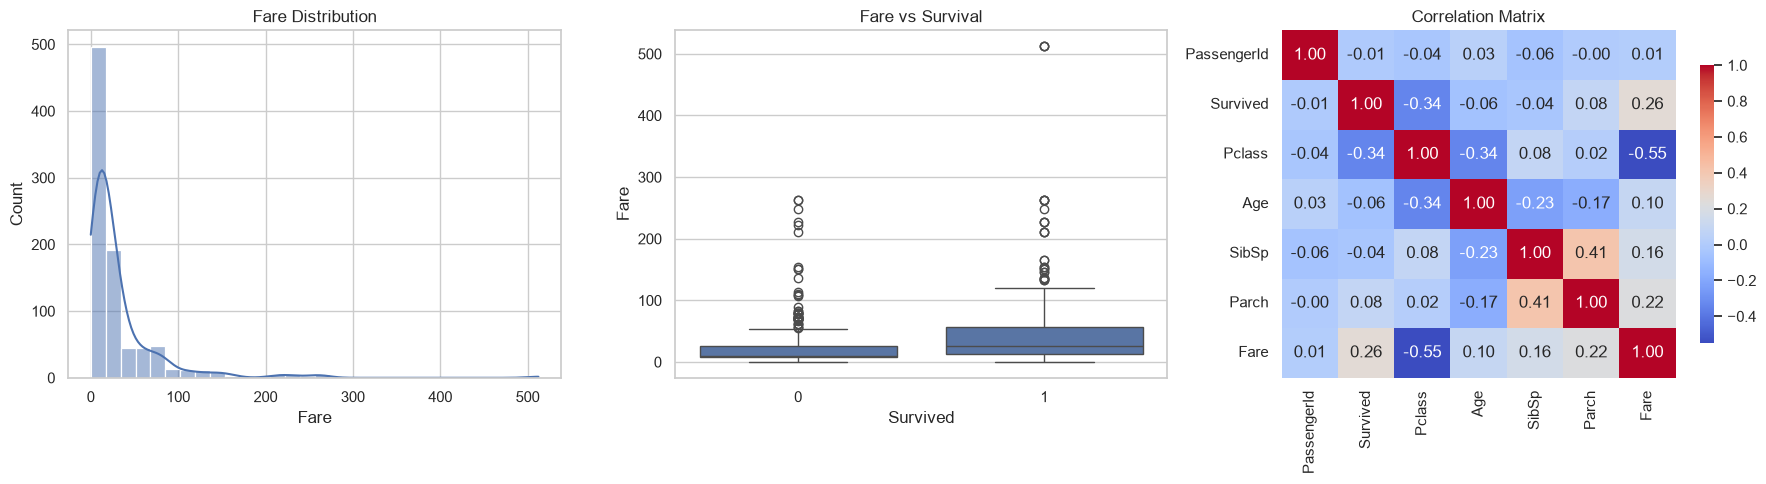

In [31]:
plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
sns.histplot(df["Fare"], kde=True, bins=30)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Count")

plt.subplot(1,3,2)
sns.boxplot(data=df, x="Survived", y="Fare")
plt.title("Fare vs Survival")
plt.xlabel("Survived")
plt.ylabel("Fare")

plt.subplot(1,3,3)
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [32]:
# Key Findings Summary

findings = {
    "Dataset Overview": {
        "Total Passengers": len(df),
        "Features": df.shape[1],
        "Missing Values": "None (after cleaning)"
    },
    "Survival Statistics": {
        "Survived": df["Survived"].sum(),
        "Did Not Survive": (df["Survived"] == 0).sum(),
        "Survival Rate": f"{df['Survived'].mean() * 100:.1f}%"
    },
    "Gender Impact": {
        "Female Survival Rate": f"{df[df['Sex'] == 'female']['Survived'].mean() * 100:.1f}%",
        "Male Survival Rate": f"{df[df['Sex'] == 'male']['Survived'].mean() * 100:.1f}%"
    },
    "Class Impact": {
        "1st Class Survival": f"{df[df['Pclass'] == 1]['Survived'].mean() * 100:.1f}%",
        "2nd Class Survival": f"{df[df['Pclass'] == 2]['Survived'].mean() * 100:.1f}%",
        "3rd Class Survival": f"{df[df['Pclass'] == 3]['Survived'].mean() * 100:.1f}%"
    },
    "Passenger Demographics": {
        "Mean Age": f"{df['Age'].mean():.1f} years",
        "Age Range": f"{df['Age'].min():.0f} - {df['Age'].max():.0f} years",
        "Mean Fare": f"${df['Fare'].mean():.2f}"
    }
}

for category, metrics in findings.items():
    print(f"\n{'='*50}")
    print(f"{category}")
    print(f"{'='*50}")
    for key, value in metrics.items():
        print(f"{key}: {value}")


Dataset Overview
Total Passengers: 891
Features: 11
Missing Values: None (after cleaning)

Survival Statistics
Survived: 342
Did Not Survive: 549
Survival Rate: 38.4%

Gender Impact
Female Survival Rate: 74.2%
Male Survival Rate: 18.9%

Class Impact
1st Class Survival: 63.0%
2nd Class Survival: 47.3%
3rd Class Survival: 24.2%

Passenger Demographics
Mean Age: 29.4 years
Age Range: 0 - 80 years
Mean Fare: $32.20


Dataset Overview

-------------------------
Total Passengers: 891
Features: 11
Missing Values: None (after cleaning)

-------------------------
Survival Statistics

Survived: 342
Did Not Survive: 549
Survival Rate: 38.4%

-------------------------
Gender Impact

Female Survival Rate: 74.2%
Male Survival Rate: 18.9%

-------------------------
Class Impact

1st Class Survival: 63.0%
2nd Class Survival: 47.3%
3rd Class Survival: 24.2%

-------------------------
Passenger Demographics

Mean Age: 29.4 years
Age Range: 0 - 80 years
Mean Fare: $32.20

====================================== WEEK 3 ========================

In [33]:
df.select_dtypes(include="number").columns

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='str')

In [34]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


The average passenger age is 29.7 years, while the median is 28 years. The mean is slightly higher than the median, indicating a slightly right-skewed distribution. The standard deviation of 14.53 years shows considerable variability in passengers' ages.

The average fare is 32.20, whereas the median is 14.45, indicating a highly right-skewed distribution. The maximum fare (512.33) is much higher than the majority of fares, suggesting the presence of extreme values (outliers).

In [36]:
df["Pclass"].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [37]:
stats = pd.DataFrame({
    "Mean": df[["Age", "Fare"]].mean(),
    "Variance": df[["Age", "Fare"]].var(),
    "Std Dev": df[["Age", "Fare"]].std()
})

stats

,Mean,Variance,Std Dev
Age,29.361582,169.512498,13.019697
Fare,32.204208,2469.436846,49.693429


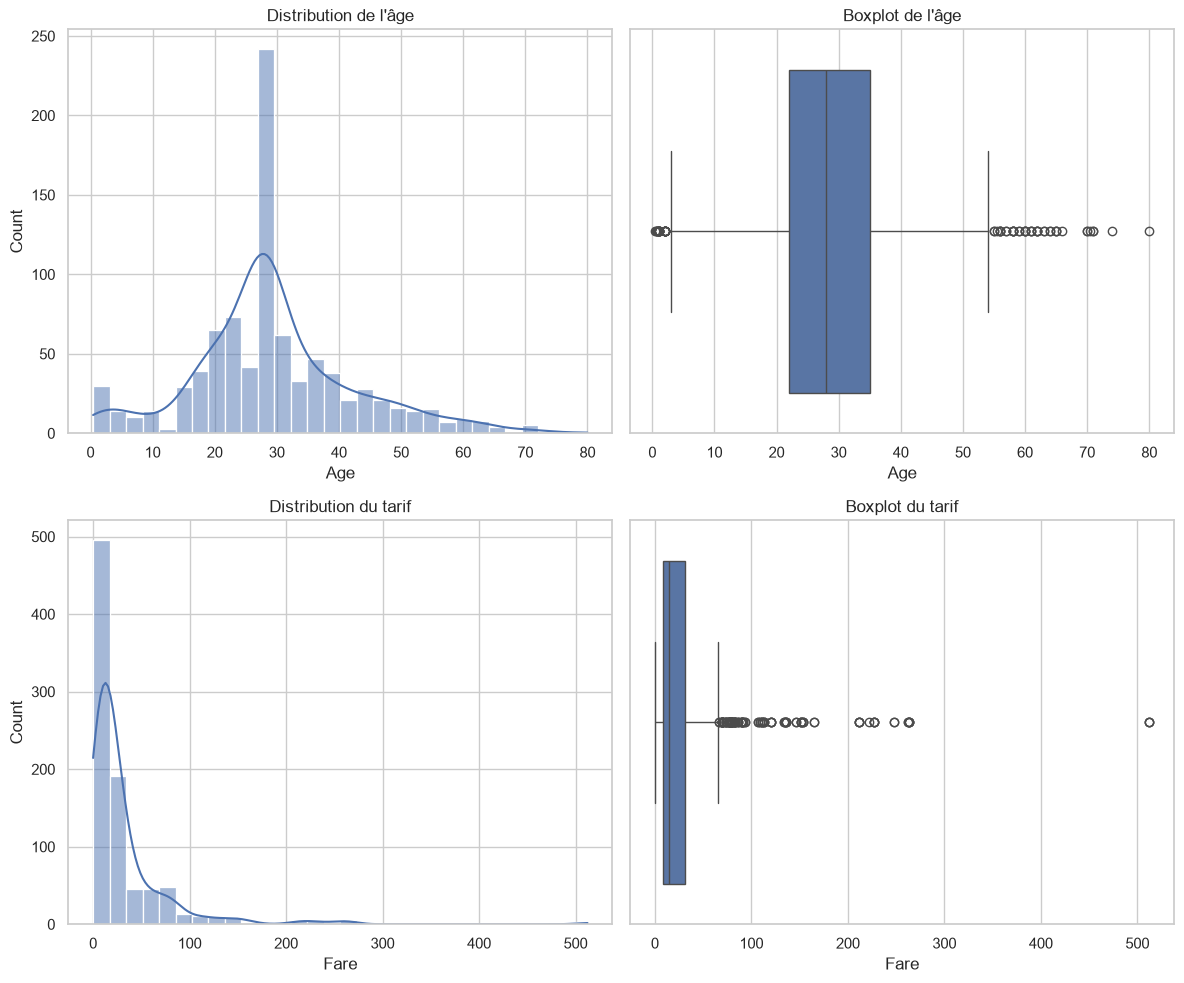

In [43]:
plt.figure(figsize=(12,10))

plt.subplot(2,2,1)
sns.histplot(df["Age"], kde=True, bins=30)
plt.title("Distribution de l'âge")

plt.subplot(2,2,2)
sns.boxplot(data=df, x="Age")
plt.title("Boxplot de l'âge")

plt.subplot(2,2,3)
sns.histplot(df["Fare"], kde=True, bins=30)
plt.title("Distribution du tarif")

plt.subplot(2,2,4)
sns.boxplot(data=df, x="Fare")
plt.title("Boxplot du tarif")

plt.tight_layout()
plt.show()

Probability Distributions - Summary
Age

The age distribution is slightly right-skewed, with most passengers between 20 and 35 years old. The boxplot shows a few older passengers as potential outliers, but these observations are realistic and do not necessarily represent errors.

Fare

The fare distribution is highly right-skewed. Most passengers paid relatively low fares, while a small number paid exceptionally high fares. The boxplot confirms the presence of several extreme values (outliers), which explains why the mean fare is considerably higher than the median.

Hypothesis Testing
Objective

Determine whether there is a statistically significant relationship between passenger sex and survival.

- hypotheses

Null Hypothesis (H₀):

Passenger sex and survival are independent. Gender has no significant effect on survival.

Alternative Hypothesis (H₁):

Passenger sex and survival are associated. Gender has a significant effect on survival.

In [44]:
from scipy.stats import chi2_contingency
contingency_table = pd.crosstab(df["Sex"], df["Survived"])
contingency_table

Survived,0,1
Sex,,
female,81,233
male,468,109


In [45]:
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square Statistic : {chi2:.4f}")
print(f"P-value              : {p_value:.6f}")
print(f"Degrees of Freedom   : {dof}")

Chi-square Statistic : 260.7170
P-value              : 0.000000
Degrees of Freedom   : 1


In [46]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
    print("There is a statistically significant association between Sex and Survival.")
else:
    print("Fail to reject H0")
    print("No statistically significant association was found.")

Reject H0
There is a statistically significant association between Sex and Survival.
